<a href="https://colab.research.google.com/github/MiguelFigueroa02/MCPI_Student_Repo/blob/main/courses/1-Semester/fundamentals%20of%20statistics/Projects/Notebooks/Estad%C3%ADstica_Descriptiva_Visualizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://raw.githubusercontent.com/MiguelFigueroa02/MCPI_Student_Repo/refs/heads/main/images/logo.png"
       width="30%">
</p>

#Fundamentos de Estadística
---
**Profesor:** Dr. Daniel de La Rosa Gómez\
**Estudiante:** Miguel Figueroa Aguilar


## 1.Descripción Breve de la base.
---



### Nombre y Fuente:
---
En este caso elegí el Dataset relacionado con el cáncer de pulmón de pacientes de 60 países compartido en la plataforma de [Kaggle](https://www.kaggle.com/datasets/laxmikantaroy/lung-cancer-risk-factors-and-survival-dataset/data)\
Este agrupa información clínica, demográfica, genética y del diagnóstico y estilo de vida relacionada con el cáncer de pulmón.

### ¿Qué representan los datos?
---
- Cubre la información clínica relevante de los pacientes incluyendo antecedentes de tabaquismo, síntomas, etapa del cáncer, tratamiento y rango de supervivencia de cada paciente

### ¿Qué representa cada fila?
---
- Cada fila representa el registro de cada uno de los pacientes incluidos en el dataset para identificar las variables asociadas con su diagnóstico.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import plotly.express as px

In [80]:
#Establecemos un formato adecuado de visualización de los dataframe que extraigamos
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth',None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [81]:
# El dataset se extrae de la plataforma de kaggle y se sube a un repositorio personal de github
url = 'https://raw.githubusercontent.com/MiguelFigueroa02/MCPI_Student_Repo/refs/heads/main/courses/1-Semester/fundamentals%20of%20statistics/Projects/Data/lung_cancer_dataset.csv'

response = requests.get(url)
if response.status_code == 200:
  print('Se accedió a dataset con éxito')
  df = pd.read_csv(url)

Se accedió a dataset con éxito


In [82]:
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Pack_Years,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,BMI_Category,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Risk_Factor_Count,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,28,39.20,Yes,No,No,Moderate,No Alcohol,29.60,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage IV,6.40,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,34,8.50,Yes,No,No,High,Heavy,31.30,Obese,Moderate,No,No,No,Yes,3,KRAS,Yes,Yes,No,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage I,2.60,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,0,0.00,Yes,No,No,High,Moderate,25.80,Overweight,Low,No,No,No,No,2,KRAS,No,No,Yes,Yes,Yes,No,No,No,No,No,3,NSCLC,Squamous Cell,Stage I,2.90,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,34,35.70,No,Yes,No,Moderate,No Alcohol,25.30,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,6,NSCLC,Adenocarcinoma,Stage IV,7.00,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,0,0.00,No,No,Yes,High,No Alcohol,32.00,Obese,Low,Yes,No,No,Yes,4,KRAS,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage III,5.80,No,Bronchoscopy,Immunotherapy,5,Yes


In [83]:
df.Diagnosis_Year = pd.to_datetime(df.Diagnosis_Year)
df.Diagnosis_Date = pd.to_datetime(df.Diagnosis_Date)

In [84]:
column_names = [f'`{column}`' for column in df.columns]
column_types = [f'`{df[column].dtype}`' for column in df.columns]
column_shapes = [len(df[column]) for column in df.columns]
column_na = [df[column].isna().sum() for column in df.columns]

In [85]:
df_analysis = pd.DataFrame({
    'Variable': column_names,
    'Tipos':column_types,
    'OObservaciones': column_shapes,
    })
# df_analysis.to_markdown(index=False)

In [86]:
print(f'La cantidad de variables son {len(df.columns)}')
print(f'La cantidad de observaciones son {df.shape[0]}')

La cantidad de variables son 46
La cantidad de observaciones son 2000


### Número de observaciones y variables
---
- El Dataset está compuesto por un total de 46 variables diferentes.
- Adicional, contiene la información de 2000 observaciones (Pacientes)\
A continuación se desglosa la información detallada de cada variable.

| Variable                   | Tipos     |   Observaciones | Descripción |
|:-------------------------:|:---------:|:---------------:|:-----------:|
| `Patient_ID`              | `object`  |            2000 |Identificador único del paciente |
| `Diagnosis_Year`          | `datetime64[ns]`   |            2000 | Año en que el paciente fue diagnosticado |
| `Diagnosis_Date`          | `datetime64[ns]`  |            2000 | Fecha completa de diagnóstico (YYYY-MM-DD) |
| `WHO_Region`              | `object`  |            2000 | Región de la OMS (WHO) |
| `Country`                 | `object`  |            2000 | País de origen |
| `Age`                     | `int64`   |            2000 | Edad de los pacientes (años) |
| `Age_Group`               | `object`  |            2000 | Grupo de 10 años (ej. 40 - 49) al que pertenece el paciente. |
| `Gender`                  | `object`  |            2000 | Género (Másculino / Femenino) |
| `Smoking_Status`          | `object`  |            2000 | Estatus de fumador |
| `Cigarettes_Per_Day`      | `int64`   |            2000 | Cantidad promedio de cigarrillos consumidos diariamente |
| `Years_Smoking`           | `int64`   |            2000 | Años Fumando |
| `Pack_Years`              | `float64` |            2000 | Cantidad acumulada de humo de tabaco expuesto por año |
| `Secondhand_Smoke`        | `object`  |            2000 | ¿Fumador Pasivo? |
| `Family_History`          | `object`  |            2000 | ¿Antecedentes Familiares? |
| `Occupational_Hazard`     | `object`  |            2000 | ¿Peligro ocupacional? |
| `Air_Pollution_Exposure`  | `object`  |            2000 | Grado de Exposición a contaminación del aire |
| `Alcohol_Use`             | `object`  |            2000 | Nivel de uso de alcohol |
| `BMI`                     | `float64` |            2000 | Índice de Masa corporal |
| `BMI_Category`            | `object`  |            2000 | Categorá de IMC |
| `Exercise_Frequency`      | `object`  |            2000 | Frecuencia de Ejercicio |
| `Chronic_Lung_Disease`    | `object`  |            2000 | ¿Enfermedad crónica de los pulmones? |
| `Asbestos_Exposure`       | `object`  |            2000 | Exposición a asbestos? |
| `Radon_Exposure`          | `object`  |            2000 | ¿Exposición a Radón? |
| `Previous_Cancer_History` | `object`  |            2000 | ¿Historia previa de cáncer ? |
| `Risk_Factor_Count`       | `int64`   |            2000 | Conteo de factores de riesgo |
| `Genetic_Mutation`        | `object`  |            2000 | Mutación genética |
| `Coughing`                | `object`  |            2000 | ¿Tos? |
| `Shortness_of_Breath`     | `object`  |            2000 | ¿Falta de aire? |
| `Chest_Pain`              | `object`  |            2000 | ¿Dolor de pecho? |
| `Coughing_Blood`          | `object`  |            2000 | ¿Tose sangre? |
| `Fatigue`                 | `object`  |            2000 | ¿fatiga? |
| `Weight_Loss`             | `object`  |            2000 | ¿Pérdida de peso? |
| `Wheezing`                | `object`  |            2000 | ¿Silbido? |
| `Recurrent_Infections`    | `object`  |            2000 | ¿Infecciones recurrentes? |
| `Swallowing_Difficulty`   | `object`  |            2000 | ¿Dificultad para tragar? |
| `Finger_Clubbing`         | `object`  |            2000 | ¿Acropauia? |
| `Symptom_Count`           | `int64`   |            2000 | Conteo de síntomas |
| `Cancer_Type`             | `object`  |            2000 | Tipo de cáncer |
| `NSCLC_Subtype`           | `object`  |            2000 | Subtipo histológico |
| `Cancer_Stage`            | `object`  |            2000 | Etapa de cáncer |
| `Tumor_Size_cm`           | `float64` |            2000 | Tamaño de tumor (cm) |
| `Metastasis`              | `object`  |            2000 | Metástasis |
| `Diagnosis_Method`        | `object`  |            2000 | Método de diagnóstico |
| `Treatment`               | `object`  |            2000 | Tratamiento |
| `Survival_Months`         | `int64`   |            2000 | Meses de supervivencia |
| `Survived`                | `object`  |            2000 | ¿Sobrevivió? |

## 2.Identificación de los tipos de variables
---

In [87]:
categoricas = [col for col in df.columns if df[col].dtype == 'object']

In [88]:
ordinales = ['Age_Group','Smoking_Status','Air_Pollution_Exposure', 'Alcohol_Use','BMI_Category','Exercise_Frequency','Cancer_Stage']

In [89]:
nominales = [categorica for categorica in categoricas if categorica not in ordinales]

In [90]:
cuant_disc = []
cuant_cont = []

for col in df.columns:
  var_type = df[col].dtype
  if var_type == 'int64':
    cuant_disc.append(col)
  elif var_type == 'float64' or var_type == '<M8[ns]':
    cuant_cont.append(col)

### Variables cuantitativas
---

In [91]:
print('Las variables Cuantitativas Discretas son:\n-'+',\n-'.join(x.strip() for x in cuant_disc))

Las variables Cuantitativas Discretas son:
-Age,
-Cigarettes_Per_Day,
-Years_Smoking,
-Risk_Factor_Count,
-Symptom_Count,
-Survival_Months


In [92]:
print('Las variables Cuantitativas Continuas son:\n-'+',\n-'.join(x.strip() for x in cuant_cont))

Las variables Cuantitativas Continuas son:
-Diagnosis_Year,
-Diagnosis_Date,
-Pack_Years,
-BMI,
-Tumor_Size_cm


### Variables categóricas
---

In [93]:
print('Las variables Categóricas Ordinales son:\n-'+',\n-'.join(x.strip() for x in ordinales))

Las variables Categóricas Ordinales son:
-Age_Group,
-Smoking_Status,
-Air_Pollution_Exposure,
-Alcohol_Use,
-BMI_Category,
-Exercise_Frequency,
-Cancer_Stage


In [94]:
df[ordinales].describe()

,Age_Group,Smoking_Status,Air_Pollution_Exposure,Alcohol_Use,BMI_Category,Exercise_Frequency,Cancer_Stage
count,2000,2000,2000,2000,2000,2000,2000
unique,6,3,3,3,4,3,4
top,50-59,Never Smoked,Moderate,Moderate,Overweight,Low,Stage I
freq,657,1311,766,811,876,772,577


In [95]:
for ordinal in ordinales:
  print(f'Los valores únicos en la variable {ordinal} son:', ", ".join(f'{descr}' for descr in df[ordinal].unique()))
  print('--'*50)

Los valores únicos en la variable Age_Group son: 40-49, 70-79, 50-59, 80-89, 60-69, 30-39
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Smoking_Status son: Current Smoker, Former Smoker, Never Smoked
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Air_Pollution_Exposure son: Moderate, High, Low
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Alcohol_Use son: No Alcohol, Heavy, Moderate
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable BMI_Category son: Overweight, Obese, Normal, Underweight
----------------------------------------------------------------------------------------------------
Los valores únicos en la variable Exercise_Frequency so

In [96]:
print('Las variables Categóricas Nominales son:\n-'+',\n-'.join(x.strip() for x in nominales))

Las variables Categóricas Nominales son:
-Patient_ID,
-WHO_Region,
-Country,
-Gender,
-Secondhand_Smoke,
-Family_History,
-Occupational_Hazard,
-Chronic_Lung_Disease,
-Asbestos_Exposure,
-Radon_Exposure,
-Previous_Cancer_History,
-Genetic_Mutation,
-Coughing,
-Shortness_of_Breath,
-Chest_Pain,
-Coughing_Blood,
-Fatigue,
-Weight_Loss,
-Wheezing,
-Recurrent_Infections,
-Swallowing_Difficulty,
-Finger_Clubbing,
-Cancer_Type,
-NSCLC_Subtype,
-Metastasis,
-Diagnosis_Method,
-Treatment,
-Survived


In [97]:
df[nominales].describe()

,Patient_ID,WHO_Region,Country,Gender,Secondhand_Smoke,Family_History,Occupational_Hazard,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Metastasis,Diagnosis_Method,Treatment,Survived
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,6,60,2,2,2,2,2,2,2,2,10,2,2,2,2,2,2,2,2,2,2,2,4,2,7,8,2
top,LC-1984,Western Pacific,Japan,Male,No,No,No,No,No,No,No,No Mutation,No,No,No,No,Yes,No,No,No,No,No,NSCLC,Adenocarcinoma,No,CT Scan,Surgery,No
freq,1,631,74,1248,1050,1483,1572,1624,1886,1847,1881,729,1024,1134,1292,1544,1323,1333,1448,1403,1717,1752,1771,1109,1441,590,410,1244


### Evaluación de datos faltantes o características importantes de la base.
---


In [98]:
disponible = df.notna().sum()
cantidad_nulos = df.isnull().sum()
porc_na = df.isna().mean()*100
vacios = (df == "").sum() | (df.apply(lambda x: str(x).isspace() if isinstance(x,str) else False)).sum()

calidad = pd.DataFrame({
    'n_disponible': disponible,
    'n_nulos': cantidad_nulos,
    '%_Valores_NA':porc_na,
    'n_vacios':vacios
})
calidad['%_Valores_NA'] = calidad['%_Valores_NA'].apply(lambda x: f'{x:.2%}')
calidad

,n_disponible,n_nulos,%_Valores_NA,n_vacios
Patient_ID,2000,0,0.00%,0
Diagnosis_Year,2000,0,0.00%,0
Diagnosis_Date,2000,0,0.00%,0
WHO_Region,2000,0,0.00%,0
Country,2000,0,0.00%,0
Age,2000,0,0.00%,0
Age_Group,2000,0,0.00%,0
Gender,2000,0,0.00%,0
Smoking_Status,2000,0,0.00%,0
Cigarettes_Per_Day,2000,0,0.00%,0


#### Interpretación
---
- El Dataset obtenido no presenta datos faltantes lo cual indica que todos los pacientes registrados cuentan con registro en todas las variables.
- El análisis estadístico puede aplicarse a todas las variables, el cual variará dependiendo del tipo de variable estadística.

## 3.Evaluación Datos Cuantitativos
---


In [99]:
def cuantitativo(df,columna):
  print(f'Se selecciona la variable cuantitativa {columna}:\n')
  print('--'*25)

  col = df[columna]
  q1 = col.quantile(0.25)
  print(f'- Resultados del primer cuartil (Q1):  {q1}\n')
  q3 = col.quantile(0.75)
  print(f'- Resultados del tercer cuartil (Q3):  {q3}\n')
  iqr = q3 - q1
  print(f'- Rango Intercuartil (IQR):  {iqr}')
  print('--'*25)

  lim_inf = q1 - (1.5 * iqr)
  atipicos_li = df[(df[columna] < lim_inf)][['Patient_ID',columna, 'Age_Group','Country','Cancer_Type','Survived']].set_index(['Patient_ID'])
  print(f'Límite inferior conforme a regla del rango IQR (1.5 veces IQR):  {lim_inf:.2f}')
  cant_atip_li = len(atipicos_li)
  print(f'Cantidad de resultados atípicos debajo de rango 1.5 veces IQR: {cant_atip_li}')
  if cant_atip_li > 0:
    print(atipicos_li.sort_values(columna,ascending=False).to_markdown())
  print('--'*25)

  mediana = col.median()
  print(f'Valor de mediana: {mediana}')
  media = col.mean()
  print(f'Valor de media: {media:.2f}')
  dev_est = col.std()
  print(f'Desviación Estándar: {dev_est:.2f}')
  print('--'*25)

  lim_sup = q3 + (1.5 * iqr)
  atipicos_su = df[(df[columna] > lim_sup)][['Patient_ID',columna, 'Age_Group','Country','Cancer_Type','Survived']].set_index(['Patient_ID'])
  print(f'Límite superior conforme a regla del rango IQR (1.5 veces IQR):  {lim_sup:.2f}')
  cant_atip_su = len(atipicos_su)
  print(f'Cantidad de resultados atípicos superiores a rango 1.5 veces IQR: {cant_atip_su}')
  if cant_atip_su > 0:
    print(atipicos_su.sort_values(columna,ascending=True).to_markdown())

In [100]:
def histograma(df,columna, unidades, title_labels='', bins='fd', kde=False, color='#1D7874',median_color='#AC3931',mode_color='#EAC435',media_color='#40376E'):
  col = df[columna]
  plt.figure(figsize=(9, 5))
  plt.style.use("dark_background")
  ax = plt.axes()
  ax.set_facecolor('#080705')
  sns.histplot(df[columna].dropna(), bins=bins, color=color, edgecolor="white",kde=kde)
  plt.axvline(col.median(), color=median_color, linewidth=2, label=f"mediana = {col.median():.2f}")
  plt.axvline(col.mean(),   color=media_color, linewidth=2, label=f"media = {col.mean():.2f}")
  plt.axvline(col.mode()[0],   color=mode_color, linewidth=2, label=f"moda = {col.mode()[0]:.2f}")
  plt.title(f"Histograma para columna {columna}. {title_labels}", fontsize=14)
  plt.xlabel(unidades,fontsize=10)
  plt.ylabel('Frecuencia',fontsize=10)
  plt.legend()
  ax.spines[['top','right']].set_visible(False)
  plt.show()

In [101]:
def boxplot(df,columna, unidades, title_labels='', bins='fd', kde=False, color='#1D7874',median_color='#AC3931',mode_color='#EAC435',media_color='#40376E'):
  col = df[columna]
  plt.figure(figsize=(9, 5))
  plt.style.use("dark_background")
  ax = plt.axes()
  ax.set_facecolor('#080705')
  boxprops = dict(facecolor="#2A7B7C", edgecolor="white", linewidth=1.5)
  whiskerprops = dict(color="white", linewidth=2)
  capprops = dict(color="white", linewidth=2)
  medianprops = dict(color="white", linewidth=2.5)
  meanprops = dict(
      marker="o", markeredgecolor="black", markerfacecolor="white", markersize=8
  )
  flierprops = dict(
      marker="o", markerfacecolor="none", markeredgecolor="white", alpha=0.6
  )

  sns.boxplot(data=df, x=columna, orient='h', ax=ax,
              showmeans=True,meanprops=meanprops,medianprops=medianprops,
              whiskerprops=whiskerprops,capprops=capprops,boxprops=boxprops,
              flierprops=flierprops
              )
  plt.axvline(col.median(), color=median_color, linewidth=2, label=f"mediana = {col.median():.2f}")
  plt.axvline(col.mean(),   color=media_color, linewidth=2, label=f"media = {col.mean():.2f}")
  plt.axvline(col.mode()[0],   color=mode_color, linewidth=2, label=f"moda = {col.mode()[0]:.2f}")
  plt.title(f"Histograma para columna {columna}. {title_labels}", fontsize=14)
  plt.xlabel(f'{columna}',fontsize=10)
  plt.ylabel(unidades,fontsize=10)
  ax.spines[['top','right','left','bottom']].set_visible(False)
  ax.set_axisbelow(True)
  ax.yaxis.grid(color='white', linestyle='--', linewidth=0.5)
  plt.legend(loc='upper right')

  plt.show()

### Columna: Cigarrillos por día (Cigarrettes_Per_Day')

#### Evaluación general de la variable

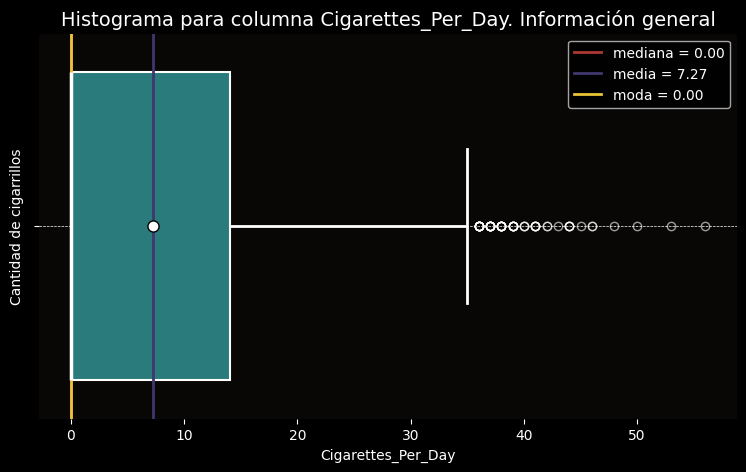

In [102]:
boxplot(df,'Cigarettes_Per_Day','Cantidad de cigarrillos',title_labels='Información general')

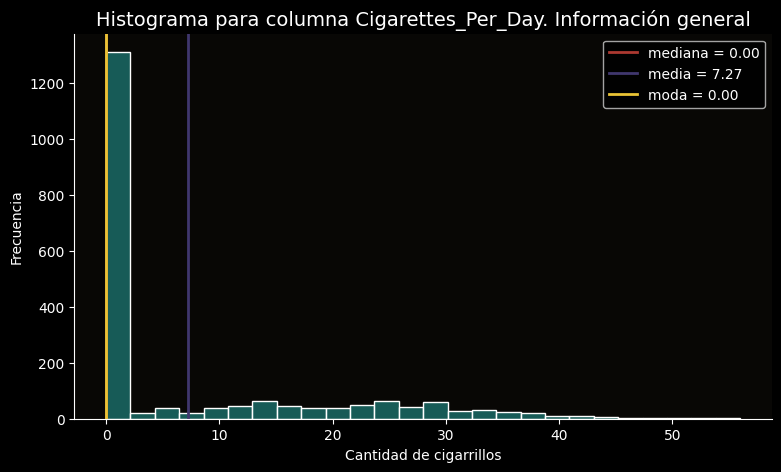

In [103]:
histograma(df,'Cigarettes_Per_Day','Cantidad de cigarrillos', title_labels='Información general')

In [104]:
cuantitativo(df,'Cigarettes_Per_Day')

Se selecciona la variable cuantitativa Cigarettes_Per_Day:

--------------------------------------------------
- Resultados del primer cuartil (Q1):  0.0

- Resultados del tercer cuartil (Q3):  14.0

- Rango Intercuartil (IQR):  14.0
--------------------------------------------------
Límite inferior conforme a regla del rango IQR (1.5 veces IQR):  -21.00
Cantidad de resultados atípicos debajo de rango 1.5 veces IQR: 0
--------------------------------------------------
Valor de mediana: 0.0
Valor de media: 7.27
Desviación Estándar: 11.67
--------------------------------------------------
Límite superior conforme a regla del rango IQR (1.5 veces IQR):  35.00
Cantidad de resultados atípicos superiores a rango 1.5 veces IQR: 59
| Patient_ID   |   Cigarettes_Per_Day | Age_Group   | Country      | Cancer_Type   | Survived   |
|:-------------|---------------------:|:------------|:-------------|:--------------|:-----------|
| LC-0037      |                   36 | 60-69       | Mongolia     | N

##### Interpretación Inicial
---
1. Se trata de una columna numérica discreta de razón, es decir, el cero indica la ausencia de esta característica en los pacientes. Por ello el registro se corta en el valor cero, a pesar de que el cálculo obtenido de los límites del IQR tiene un valor negativo.
2. Esta variable representa la cantidad de cigarrillos consumidos por los pacientes diariamiente. Sin embargo, El dataset considera situaciones adicionales relacionadas por factores ajenos al consumo del cigarro. Es por ello que la mayoría de las observaciones presentan una mediana y moda igual a cero, provocando un sesgo a la izquierda con una prolongada cola hacia la derecha sucitada por la combinación de registros de fumadores habituales. En un subsecuente análisis posterior se descatarán los registros de usuarios que no fuman para determinar la distribución de registros de pacientes con el consumo de cigarros.
3. Asimismo, la cantidad de registros de usuarios que no consumen el cigarro provoca una gran cantidad de outliers de pacientes con consumo habitual de cigarro en el extremo superior, por lo que sería conveniente el descarte de estos resultados para una evaluación más confiable sobre la relación habitual del consumo de cigarrillos con el desarrollo del cáncer pulmonar y verificar su distribución para concluir si estos registros son atípicos.\

Considerando lo anterior, se procede a filtrar resultados a partir de la columna `Smoking_Status` para identificar a los pacientes con consumo habitual de cigarrillos.

#### Evaluación únicamente de fumadores
---


In [105]:
df_smokers = df[(df['Smoking_Status'].apply(lambda x: x in ['Current Smoker', 'Former Smoker']))].copy()
df_smokers.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Pack_Years,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,BMI_Category,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Risk_Factor_Count,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,1970-01-01 00:00:00.000002020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,28,39.20,Yes,No,No,Moderate,No Alcohol,29.60,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage IV,6.40,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,1970-01-01 00:00:00.000002021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,34,8.50,Yes,No,No,High,Heavy,31.30,Obese,Moderate,No,No,No,Yes,3,KRAS,Yes,Yes,No,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage I,2.60,No,Biopsy,Surgery + Chemotherapy,76,Yes
3,LC-0004,1970-01-01 00:00:00.000002018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,34,35.70,No,Yes,No,Moderate,No Alcohol,25.30,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,6,NSCLC,Adenocarcinoma,Stage IV,7.00,Yes,CT Scan,Chemotherapy,9,No
12,LC-0013,1970-01-01 00:00:00.000002022,2022-06-09,Europe,France,57,50-59,Female,Current Smoker,14,20,14.00,Yes,Yes,No,Moderate,Moderate,26.30,Overweight,High,No,No,No,No,2,No Mutation,Yes,No,Yes,No,Yes,No,Yes,No,No,No,4,NSCLC,Squamous Cell,Stage III,7.00,No,Biopsy,Immunotherapy,17,No
18,LC-0019,1970-01-01 00:00:00.000002017,2017-02-13,Europe,Germany,60,60-69,Female,Former Smoker,17,18,15.30,No,No,No,Low,Moderate,22.60,Normal,Low,Yes,No,No,No,1,ALK,No,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,6,SCLC,Not Applicable,Stage II,4.90,No,Bronchoscopy,Surgery + Chemotherapy,51,No


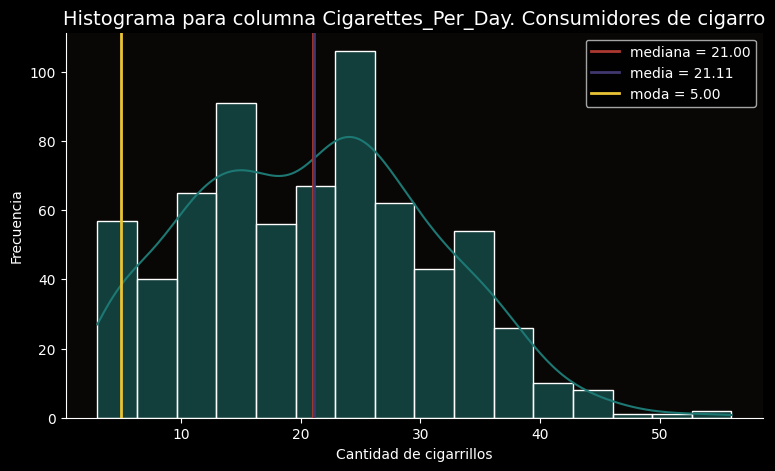

In [106]:
histograma(df_smokers,'Cigarettes_Per_Day','Cantidad de cigarrillos', title_labels='Consumidores de cigarro', kde=True)

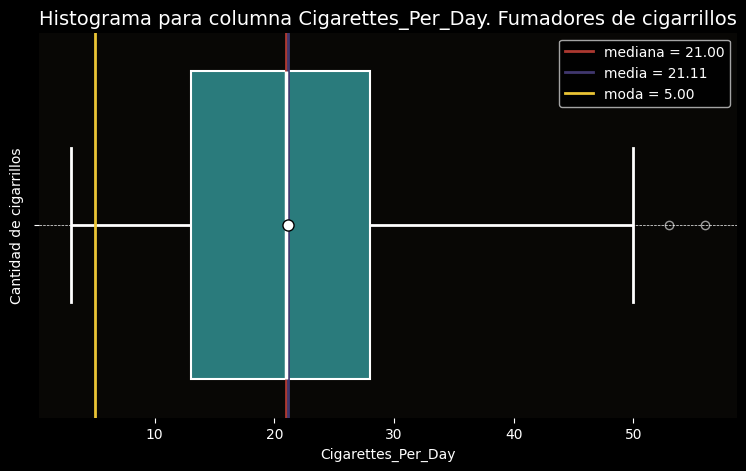

In [107]:
boxplot(df_smokers,'Cigarettes_Per_Day','Cantidad de cigarrillos',title_labels='Fumadores de cigarrillos')

In [108]:
cuantitativo(df_smokers,'Cigarettes_Per_Day')

Se selecciona la variable cuantitativa Cigarettes_Per_Day:

--------------------------------------------------
- Resultados del primer cuartil (Q1):  13.0

- Resultados del tercer cuartil (Q3):  28.0

- Rango Intercuartil (IQR):  15.0
--------------------------------------------------
Límite inferior conforme a regla del rango IQR (1.5 veces IQR):  -9.50
Cantidad de resultados atípicos debajo de rango 1.5 veces IQR: 0
--------------------------------------------------
Valor de mediana: 21.0
Valor de media: 21.11
Desviación Estándar: 10.16
--------------------------------------------------
Límite superior conforme a regla del rango IQR (1.5 veces IQR):  50.50
Cantidad de resultados atípicos superiores a rango 1.5 veces IQR: 2
| Patient_ID   |   Cigarettes_Per_Day | Age_Group   | Country    | Cancer_Type   | Survived   |
|:-------------|---------------------:|:------------|:-----------|:--------------|:-----------|
| LC-0137      |                   53 | 60-69       | Bangladesh | NSCLC 

In [109]:
porc_fumadores = (len(df_smokers)/len(df))
cant_fumadores = len(df_smokers)
print(f'La cantidad de pacientes con consumo de cigarro es igual a {cant_fumadores}')
print(f'La proporción de pacientes fumadores es de {porc_fumadores:.2%}')

La cantidad de pacientes con consumo de cigarro es igual a 689
La proporción de pacientes fumadores es de 34.45%


In [110]:
columna = df_smokers.Cigarettes_Per_Day
print(f'La asimetría para esta variable es igual a {columna.skew():.6f}')
print(f'La evaluación de la Curtosis es igual a {columna.kurt():.7f}')

La asimetría para esta variable es igual a 0.230898
La evaluación de la Curtosis es igual a -0.4536959


##### Interpretación
---
1. Los valores de la media (21.11) y la mediana (21.00) son muy cercanos entre sí, lo que es un primer indicativo de que los registros de  cigarrillos por día para los fumadores son uniformes.
2. El 50 % de las observaciones se encuentran entre el rango de 13.0 a 28.0, lo cual contrasta con el total de registros evaluados de manera inicial en donde dicho rango de distribución de registros se encontraban entre 0.0 y 14.0
3. Para esta segunda evaluación de la distribución del consumo de cigarrillos por día se descartaron los registros de 1311 pacientes, los cuales no consumen o han consumido cigarro. Por lo cual. El Dataset incluye factores adicionales relacionados con el desarrollo del cáncer de pulmón.
4. El consumo de cigarro en estos 689 pacientes restantes muestra una ligera cola hacia la derecha y dos registros que pueden considerarse como atípicos sobre el extremo superior de la distribución. Sin embargo, esto se diferencía con respecto a la evaluación general de esta columna en donde al incluir los valores de los no fumadores la evaluación arrojaba 59 valores atípicos.
5. El valor de asimetría tiene un resultado positivo pero menor a 0.5, lo cual confirma la ligera cola hacia la derecha pero sin tener una afectación mayor sobre la distribución de los datos lo cual se confirma teniendo en cuenta la cercanía de los valores de la media y mediana.
6. El valor de la curtosis negativa indica una tendencia de los datos hacia una distribución platicúrtica, lo cual está relacionado con el valor de de desviación estándar de 10.16. En el histograma se incluye la línea de tendencia para ejemplificar la forma que sigue esta distribución de los datos.

## 4.Evaluación de variable categórica
---

In [111]:
def categorica(df,columna):
  categorica = pd.DataFrame({'Cuenta':df[columna].value_counts().sort_index()})
  categorica['% Porcentaje'] = (df[columna].value_counts(normalize=True).round(5))*100
  categorica['% Acumulado'] = categorica['% Porcentaje'].cumsum()
  return categorica

In [112]:
df_cancer_stage = categorica(df, 'Cancer_Stage')
print(df_cancer_stage.to_markdown())

| Cancer_Stage   |   Cuenta |   % Porcentaje |   % Acumulado |
|:---------------|---------:|---------------:|--------------:|
| Stage I        |      577 |          28.85 |         28.85 |
| Stage II       |      487 |          24.35 |         53.2  |
| Stage III      |      460 |          23    |         76.2  |
| Stage IV       |      476 |          23.8  |        100    |


In [113]:
def tabla_cruzada(df, col1, col2, normalize= False):
  if normalize:
    tabla = pd.crosstab(df[col1], df[col2], margins=True, margins_name='Total',normalize=True).apply(lambda x: x.round(5)*100)
  else:
    tabla = pd.crosstab(df[col1], df[col2], margins=True, margins_name='Total')
  return tabla

In [114]:
cancer_stage_type = tabla_cruzada(df, 'Cancer_Stage','Cancer_Type')
cancer_stage_type

Cancer_Type,NSCLC,SCLC,Total
Cancer_Stage,,,
Stage I,529,48,577
Stage II,432,55,487
Stage III,396,64,460
Stage IV,414,62,476
Total,1771,229,2000


In [116]:
cancer_stage_type_2 = tabla_cruzada(df, 'Cancer_Stage','Cancer_Type',normalize=True)
cancer_stage_type_2

Cancer_Type,NSCLC,SCLC,Total
Cancer_Stage,,,
Stage I,26.45,2.40,28.85
Stage II,21.60,2.75,24.35
Stage III,19.80,3.20,23.00
Stage IV,20.70,3.10,23.80
Total,88.55,11.45,100.00


In [125]:
df['Cancer_Stage'].value_counts().sum()

np.int64(2000)

In [169]:
def pastel(df,columna, title_labels='', color='#1D7874', normalize=False, edgecolor='White',color_palette="Paired"):
  plt.figure(figsize=(7, 7))
  plt.style.use("dark_background")
  ax = plt.axes()
  ax.set_facecolor('#080705')
  colores = sns.color_palette(color_palette, len(df[columna].value_counts()))
  if normalize:
    col = df[columna].value_counts(normalize=True)
    plt.pie(col,labels=col.index, autopct='%1.1f%%', startangle=90, colors=colores,
            wedgeprops=dict(edgecolor=edgecolor,width= 0.6),pctdistance=0.8,
            textprops={'fontsize': 12,'fontweight': 'bold'})
  else:
    col = df[columna].value_counts()
    sns.pie(col,labels=col.index, autopct=lambda p: f'{(int(p * df[columna].value_counts().sum())/100)}', startangle=90,
            colors=colores,wedgeprops=dict(edgecolor=edgecolor,width= 0.6),pctdistance=0.8,
            textprops={'fontsize': 12,'fontweight': 'bold'})


  plt.title(f"Histograma para columna {columna}. {title_labels}", fontsize=14)
  plt.show()

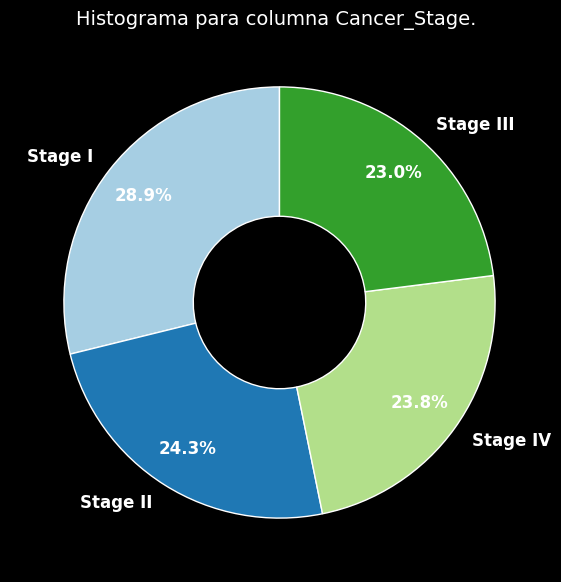

In [170]:
pastel(df,'Cancer_Stage',normalize=True)